## Imports

In [3]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pandas as pd
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import thresholds_functions as th
import pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Historical Plot

In [4]:
sweden_cohort = HMD(country = 'swe', gender = 'both', data_type = 'cohort')
sweden_period = HMD(country = 'swe', gender = 'both', data_type = 'period')

denmark_period = HMD(country = 'dan', gender = 'both', data_type = 'period')
denmark_cohort = HMD(country = 'dan', gender = 'both', data_type = 'cohort')

0.9373422408820373 0.9487509508563562


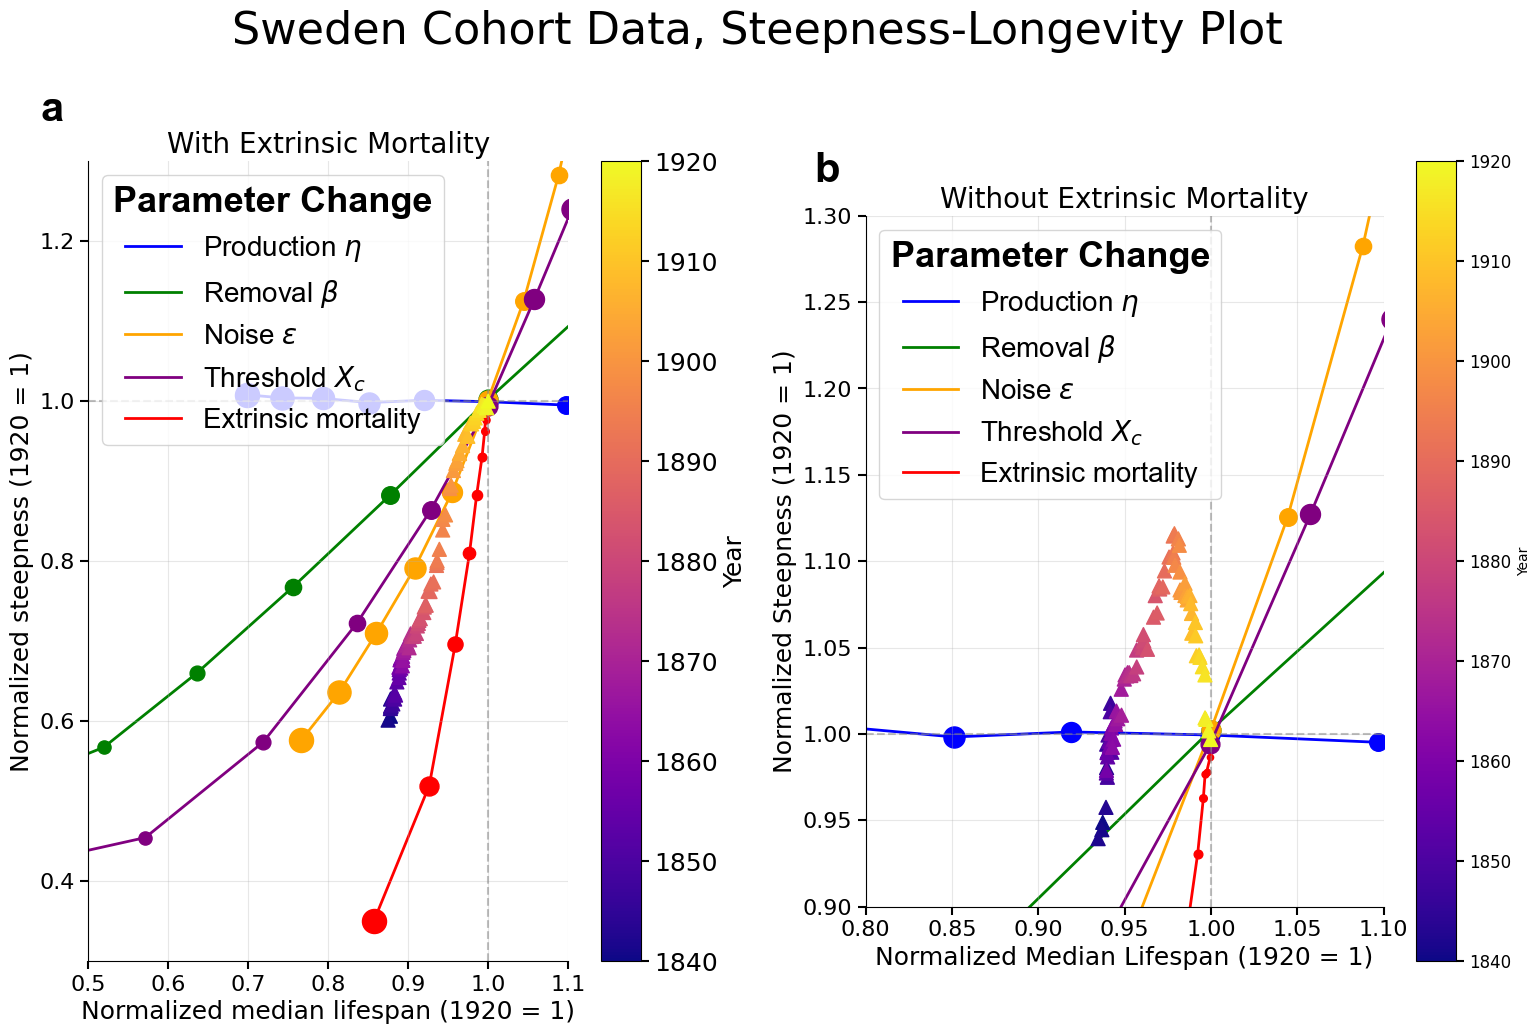

In [5]:
year_start = 1840; year_end = 1920
years = np.arange(year_start, year_end+1, 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

ref_year = year_end
age_start = 20;  ages_end = 40
hmd = sweden_cohort
interval = 5

# Left subplot - with extrinsic mortality
th.plot_steepness_longevity(param_type = 'variation', from_t = age_start, 
                            h_ext = True, ax = ax1, marker_size_range = (20, 300))

norm_medians, norm_steepnesses = th.plot_historical_changes(hmd, years, ax = ax1, 
                                                            without_extrinsic = False, ref_year = ref_year, from_t = age_start, cmap = 'plasma')
ax1.set_xlim(0.5, 1.1)
ax1.set_ylim(0.3, 1.3)  
ax1.set_title('With Extrinsic Mortality', fontsize=20)
ax1.tick_params(labelsize=16)

# Create legend with larger fontsize
handles1, labels1 = ax1.get_legend_handles_labels()
if handles1:
    ax1.legend(handles1, labels1, fontsize=18)

# Right subplot - without extrinsic mortality
th.plot_steepness_longevity(param_type = 'variation', from_t = age_start, 
                            h_ext = True, ax = ax2, marker_size_range = (20, 300)) 

norm_medians, norm_steepnesses = th.plot_historical_changes(hmd, years, ax = ax2, 
                                                            without_extrinsic = True, ref_year = ref_year, from_t = age_start, cmap = 'plasma')
ax2.set_title('Without Extrinsic Mortality', fontsize=20)
ax2.set_xlim(0.8, 1.1)
ax2.set_ylim(0.9, 1.3)
ax2.tick_params(labelsize=16)

# Create legend with larger fontsize
handles2, labels2 = ax2.get_legend_handles_labels()
if handles2:
    ax2.legend(handles2, labels2, fontsize=18)

# Set axis label font sizes for both subplots
for ax in [ax1, ax2]:
    ax.xaxis.label.set_fontsize(18)
    ax.yaxis.label.set_fontsize(18)

# Adjust colorbar font sizes to match axis labels
for ax in [ax1, ax2]:
    # Find colorbar associated with this axis
    for child in ax.figure.get_children():
        if hasattr(child, 'colorbar') and hasattr(child.colorbar, 'ax'):
            if child.colorbar.ax.get_position().x0 > ax.get_position().x0:  # Colorbar is to the right
                child.colorbar.ax.tick_params(labelsize=16)
                child.colorbar.set_label('Year', fontsize=18)

fig.suptitle('Sweden Cohort Data, Steepness-Longevity Plot', fontsize=32, y=1.02)


# Add subplot labels (a) and (b)
ax1.text(-0.1, 1.05, 'a', transform=ax1.transAxes, 
        fontsize=30, fontweight='bold', fontname='Arial')
ax2.text(-0.1, 1.05, 'b', transform=ax2.transAxes, 
        fontsize=30, fontweight='bold', fontname='Arial')

plt.tight_layout()

<Axes: title={'center': 'Extrinsic Mortality over Time'}, xlabel='Year', ylabel='Extrinsic Mortality [1/years]'>

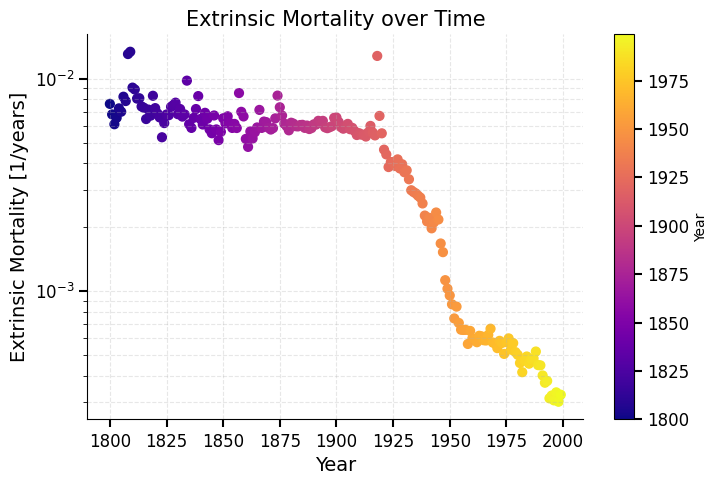

In [ ]:
sweden_period.plot_makeham_term_trend(years = np.arange(1800, 2000, 1))

## cohort

Text(0.5, 0.98, 'Denmark Steepness Longevity over time (survival curves from age = 20 yrs)')

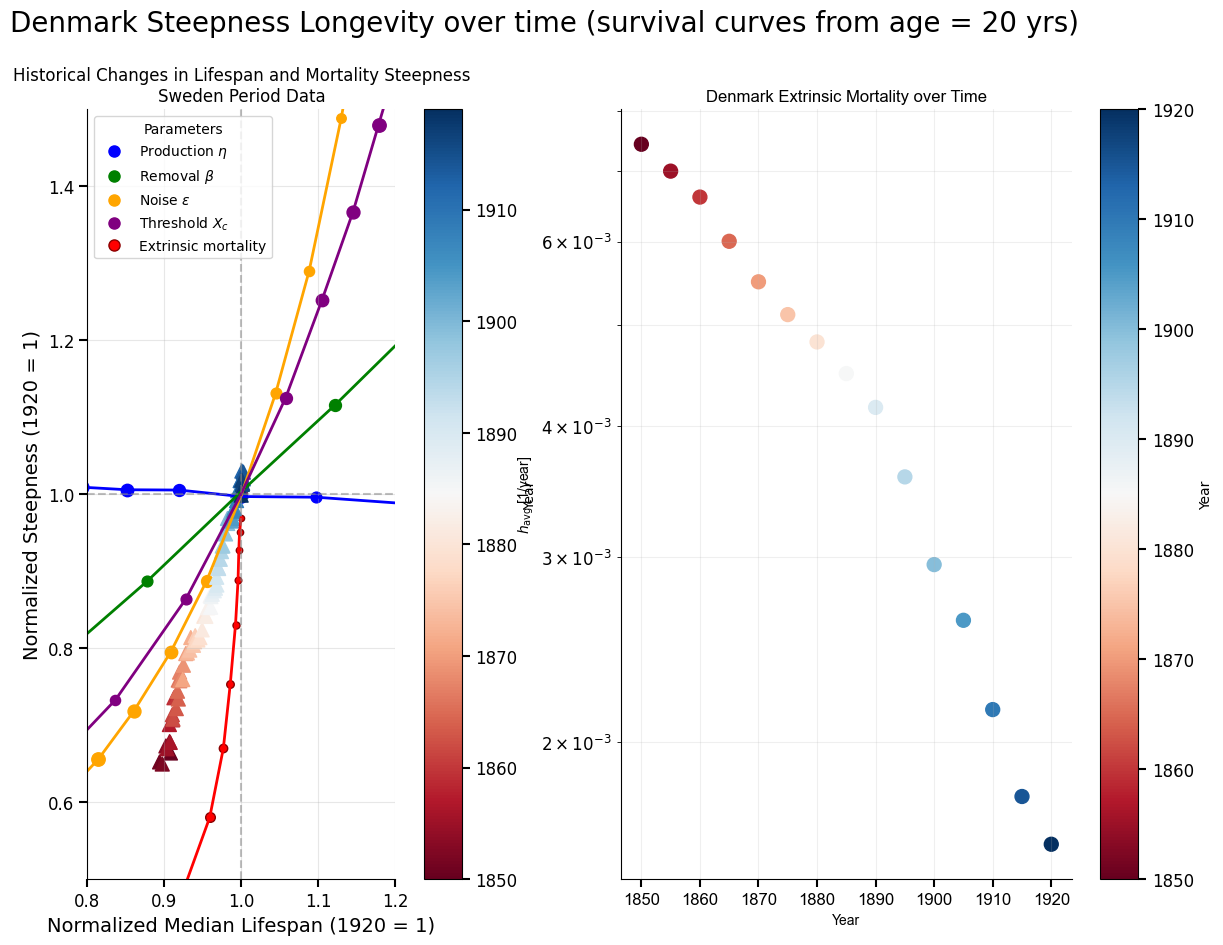

In [ ]:
year_start = 1840; year_end = 1920
years = np.arange(year_start, year_end, 1)
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18, 10))
ref_year = year_end
age_start = 20;  ages_end = 40
hmd = denmark_cohort
interval = 5
th.plot_steepness_longevity(param_type = 'variation', from_t = age_start, 
                            h_ext = True, ax = ax1)
norm_medians, norm_steepnesses = th.plot_historical_changes(hmd, years, ax = ax1, 
                                                            without_extrinsic = True, ref_year = ref_year, from_t = age_start)
ax1.set_xlim(0.5, 1.1)
ax1.set_ylim(0.3, 1.2)  
ax1.set_title('Without Extrinsic Mortality')
# ax 2
th.plot_steepness_longevity(param_type = 'variation', from_t = age_start, 
                            h_ext = True, ax = ax2) 

# sweden_period.plot_average_hazard_over_age_interval(year_start=year_start,year_end=year_end,interval=1, ages_end = 40, ax=ax2,label = 'Sweden', error_bars=False)
norm_medians, norm_steepnesses = th.plot_historical_changes(hmd, years, ax = ax2, 
                                                            without_extrinsic = False, ref_year = ref_year, from_t = age_start)
ax2.set_title('With Extrinsic Mortality')
ax2.set_xlim(0.5, 1.1)
ax2.set_ylim(0.3, 1.2)
fig.suptitle('Sweden Steepness Longevity over time (survival curves from age = 20 yrs)', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)


## cleaning up extrinsic

cohort data

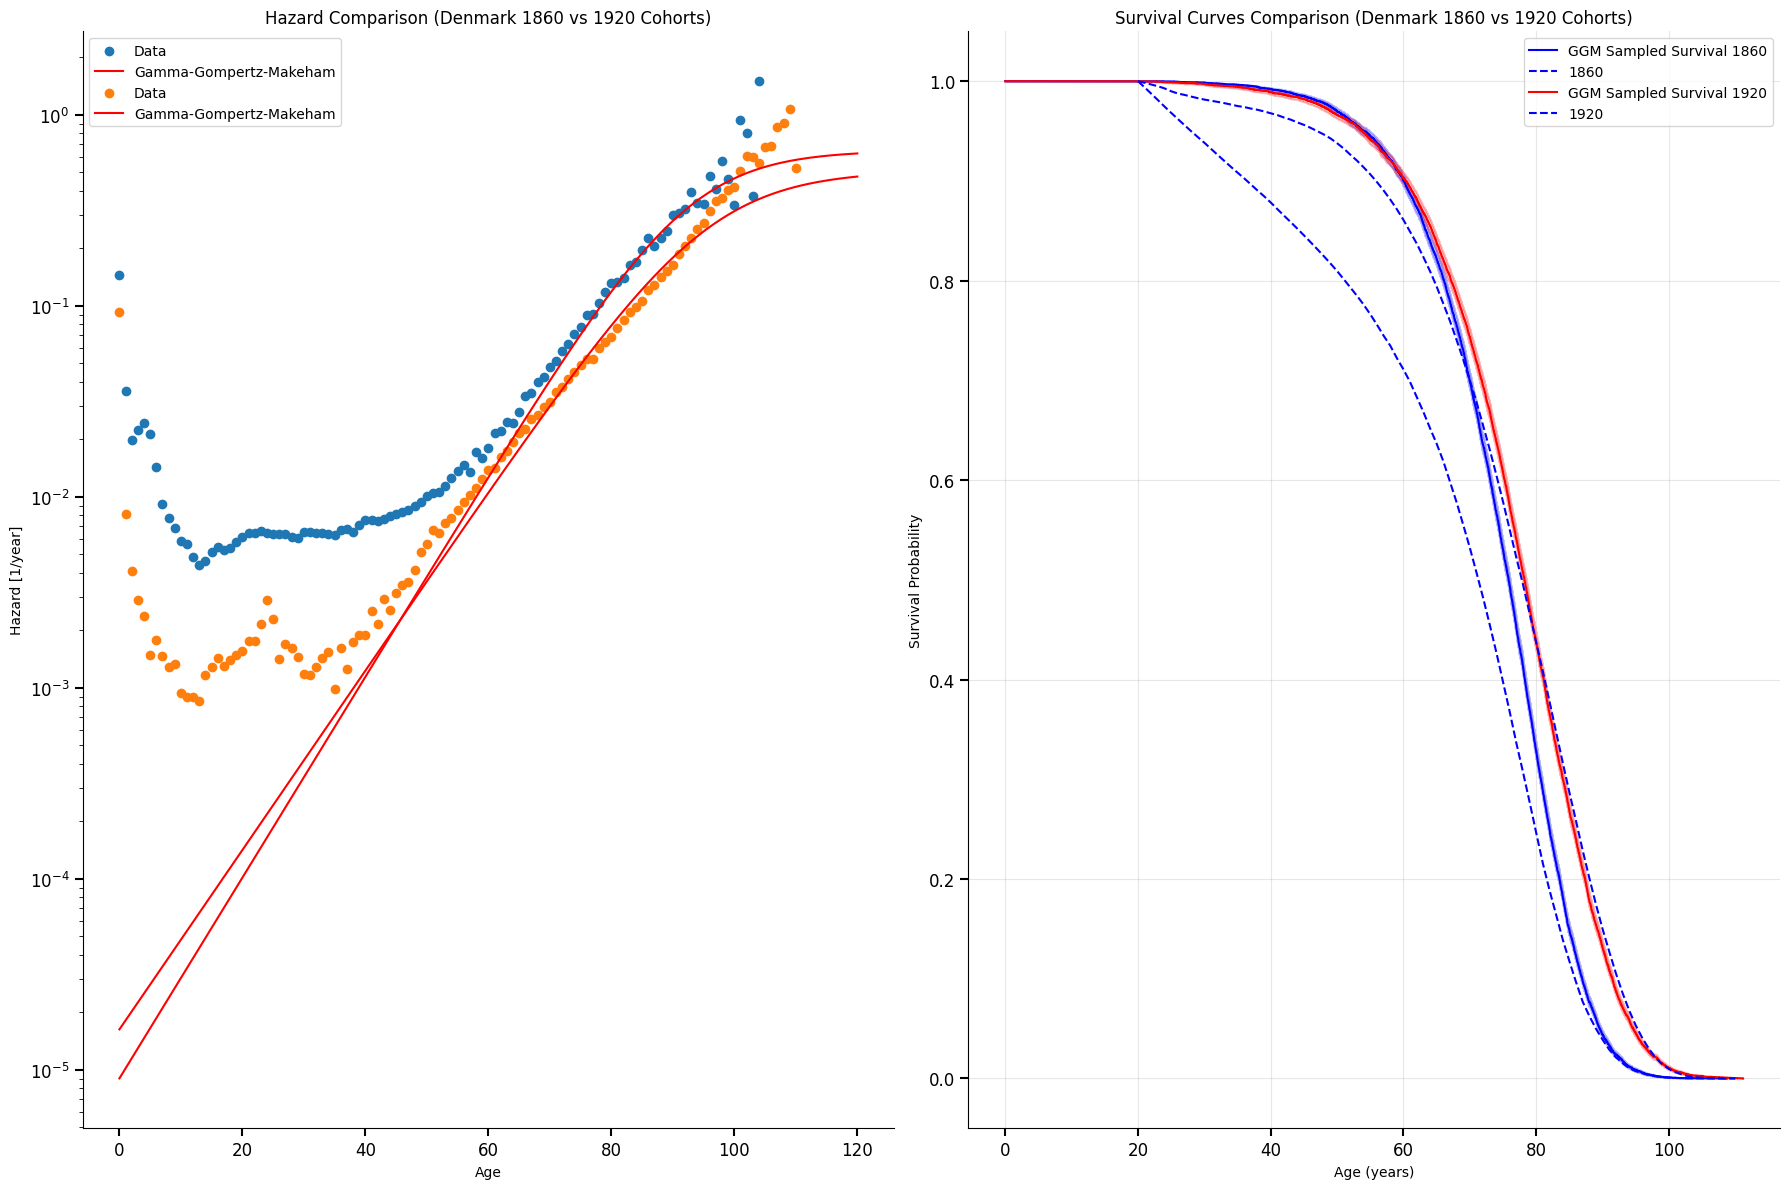

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))
years = [1860, 1920]
colors = ['blue', 'red']

# Left plot: Hazard comparison
for i, year in enumerate(years):
    mgg = denmark_cohort.fit_ggm(year = year)
    gg_temp = gg()
    gg_temp.a = mgg['a']
    gg_temp.b = mgg['b']
    gg_temp.c = mgg['c']
    gg_temp.m = 0

    death_times = gg_temp.sample_death_times(n = 10000, min_age = 20)
    gg_temp.plot_hazard_with_data_comparison(country = 'dan', year = year, gender = 'both', 
                                            data_type = 'cohort', haz_type = 'mx', ax=ax1)

    # Right plot: Survival curves
    # Plot Kaplan-Meier from sampled death times
    kmf = KaplanMeierFitter()
    kmf.fit(death_times)
    kmf.plot_survival_function(ax=ax2, label=f'GGM Sampled Survival {year}', color=colors[i])

    # Plot actual cohort survival
    denmark_cohort.plot_conditional_survival(age_X = 20, years = year, ax=ax2, linestyle='--')

ax1.set_title('Hazard Comparison (Denmark 1860 vs 1920 Cohorts)')
ax2.set_title('Survival Curves Comparison (Denmark 1860 vs 1920 Cohorts)')
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Survival Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


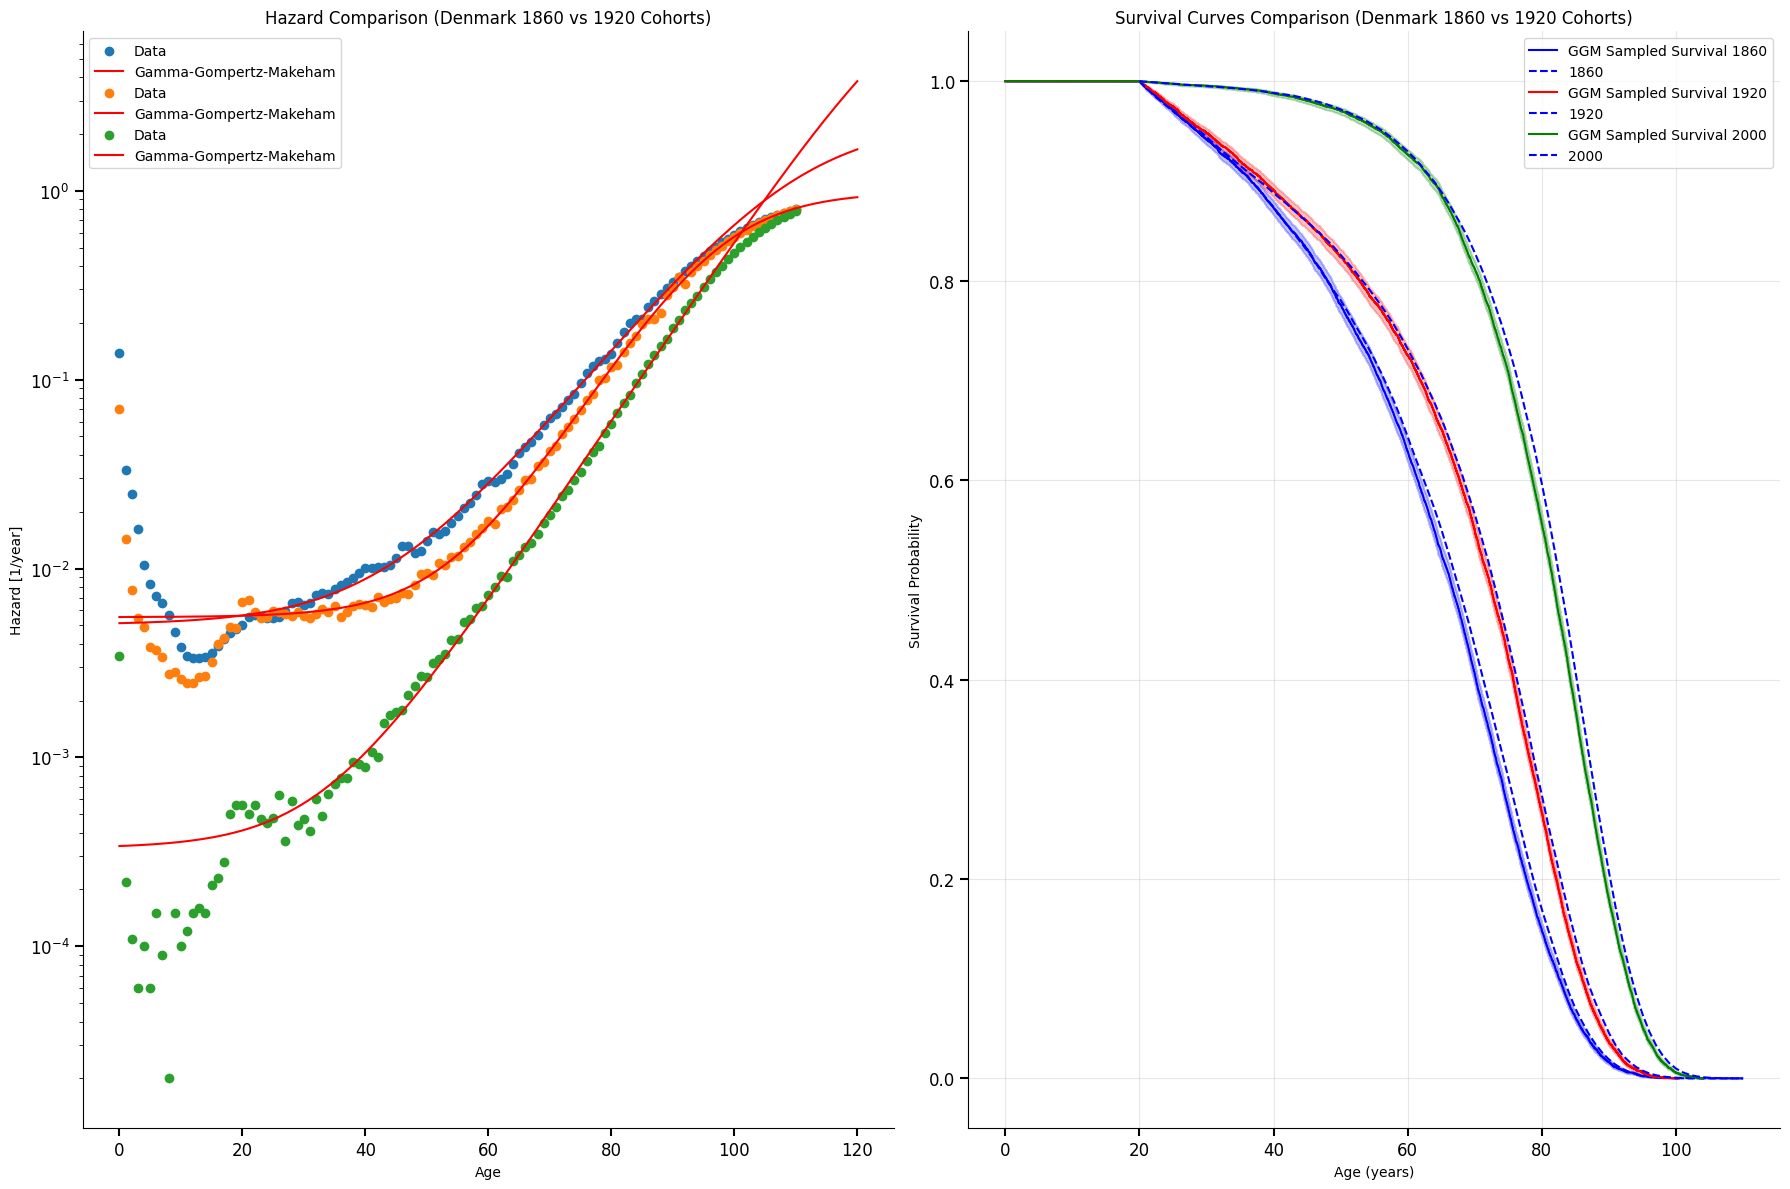

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))
years = [1860, 1920, 2000]
colors = ['blue', 'red', 'green']
hmd = sweden_period
# Left plot: Hazard comparison
for i, year in enumerate(years):
    mgg = hmd.fit_ggm(year = year)
    gg_temp = gg()
    gg_temp.a = mgg['a']
    gg_temp.b = mgg['b']
    gg_temp.c = mgg['c']
    gg_temp.m = mgg['m']

    death_times = gg_temp.sample_death_times(n = 10000, min_age = 20)
    gg_temp.plot_hazard_with_data_comparison(country = 'swe', year = year, gender = 'both', 
                                            data_type = 'period', haz_type = 'mx', ax=ax1)

    # Right plot: Survival curves
    # Plot Kaplan-Meier from sampled death times
    kmf = KaplanMeierFitter()
    kmf.fit(death_times)
    kmf.plot_survival_function(ax=ax2, label=f'GGM Sampled Survival {year}', color=colors[i])

    # Plot actual cohort survival
    hmd.plot_conditional_survival(age_X = 20, years = year, ax=ax2, linestyle='--')

ax1.set_title('Hazard Comparison (Denmark 1860 vs 1920 Cohorts)')
ax2.set_title('Survival Curves Comparison (Denmark 1860 vs 1920 Cohorts)')
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Survival Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()
